# Baseline Model

In [ ]:
# ===================================================================
# PHASE 1: DATA SETUP (CIFAKE DATASET)
# ===================================================================

import os
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Install and Configure Kaggle
# We need this to download the dataset.
!pip install kaggle

# 2. Upload your 'kaggle.json' API token
# When you run this, a file upload prompt will appear.
# You must upload your Kaggle API key.
from google.colab import files

if not os.path.exists("/root/.kaggle/kaggle.json"):
    print("Please upload your kaggle.json file:")
    uploaded = files.upload()
    if "kaggle.json" not in uploaded:
        print("\nERROR: kaggle.json was not uploaded. Halting.")
    else:
        print("\nkaggle.json uploaded successfully.")
        !mkdir -p ~/.kaggle
        !cp kaggle.json ~/.kaggle/
        !chmod 600 ~/.kaggle/kaggle.json
        print("Kaggle API configured.")
else:
    print("Kaggle.json already exists.")

# 3. Download the CIFAKE Dataset
# This is the 120,000-image dataset specified in the plan.
dataset_name = 'cifake-real-and-ai-generated-synthetic-images'
dataset_path = '/content/CIFAKE'

if not os.path.exists(dataset_path):
    print(f"\nDownloading dataset: {dataset_name}...")
    # This is the correct Kaggle API command for the CIFAKE dataset
    !kaggle datasets download -d birdy654/cifake-real-and-ai-generated-synthetic-images -p /content/

    print("\nUnzipping dataset...")
    # The downloaded file is a zip. We need to unzip it.
    !unzip -q /content/cifake-real-and-ai-generated-synthetic-images.zip -d {dataset_path}
    print("Unzipping complete. Dataset is ready.")
else:
    print(f"\nDataset already downloaded and unzipped in {dataset_path}")

# 4. Verify Directory Structure
print("\nVerifying dataset structure:")
!ls -l {dataset_path}
print("\nContents of 'train' directory:")
!ls -l {dataset_path}/train

In [ ]:
# ===================================================================
# PHASE 1: DATA PIPELINE (tf.data)
# ===================================================================

# 1. Define Constants
# These are based on our research plan.
IMG_HEIGHT = 32  # CIFAKE images are 32x32, matching CIFAR-10
IMG_WIDTH = 32
BATCH_SIZE = 64  # Start with 64, as recommended in the plan's tuning section
SEED = 123       # For reproducible results

# 2. Define Data Directories
# These paths MUST match the unzipped structure from Task 1.
train_dir = os.path.join(dataset_path, 'train')
test_dir = os.path.join(dataset_path, 'test')

# 3. Create Training and Validation Datasets
# We load the *entire* 'train' directory (100,000 images)
# and split it 80/20 into training and validation sets.
print("Creating training and validation datasets...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode='binary',        # REAL=1, FAKE=0 (since FAKE is alphabetically first)
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    seed=SEED,
    validation_split=0.2,       # 20% for validation
    subset='training'           # This is the 80% training part
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,  # We split from the *same* training directory
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    seed=SEED,
    validation_split=0.2,       # 20% for validation
    subset='validation'         # This is the 20% validation part
)

# 4. Create the Test Dataset
# The 'test' directory (20,000 images) is kept separate for final evaluation.
print("Creating test dataset...")
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False  # No need to shuffle the test set
)

# 5. Verify Class Names
# FAKE should be 0, REAL should be 1.
class_names = train_dataset.class_names
print(f"\nClass names found: {class_names}")
if class_names != ['FAKE', 'REAL']:
    print("WARNING: Class order is unexpected. Verify labels.")
else:
    print("Class mapping: FAKE -> 0.0, REAL -> 1.0")

# 6. Configure Data Augmentation and Preprocessing
# As per the plan: Normalization and Augmentation.
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal", seed=SEED),
        tf.keras.layers.RandomRotation(0.1, seed=SEED),
        tf.keras.layers.RandomZoom(0.1, seed=SEED),
    ],
    name="data_augmentation",
)

# This layer will rescale pixel values from [0, 255] to [0, 1]
rescale_layer = tf.keras.layers.Rescaling(1./255)

# 7. Apply Preprocessing and Performance Tuning
AUTOTUNE = tf.data.AUTOTUNE

def prepare_dataset(ds, augment=False, shuffle_buffer_size=1000):
    # Rescale all datasets
    ds = ds.map(lambda x, y: (rescale_layer(x), y), num_parallel_calls=AUTOTUNE)

    # Cache before shuffling and augmentation
    ds = ds.cache()

    if augment:
        # Apply augmentation only to the training set
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)

    # Prefetch for performance
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds

train_dataset = prepare_dataset(train_dataset, augment=True)
validation_dataset = prepare_dataset(validation_dataset, augment=False)
test_dataset = prepare_dataset(test_dataset, augment=False)

print("\nData pipeline built and configured.")

# 8. Final Sanity Check
# Let's look at one batch to see the shape and value range
print("\nInspecting one batch from the training dataset:")
for images, labels in train_dataset.take(1):
    print(f"  Images batch shape: {images.shape}")
    print(f"  Labels batch shape: {labels.shape}")
    print(f"  Min pixel value: {tf.reduce_min(images).numpy()}")
    print(f"  Max pixel value: {tf.reduce_max(images).numpy()}")

In [ ]:
# ===================================================================
# PHASE 2: BASELINE MODEL
# ===================================================================

from tensorflow.keras import layers, models

# 1. Define Model Architecture
# This is the same architecture as your V1, now ready for real data.
# Rescaling is already handled in our data pipeline.

baseline_model = models.Sequential([
    # Input layer specifies the shape (32x32 images, 3 color channels)
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # First convolutional block
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Second convolutional block
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Third convolutional block
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Flatten the results to feed into a dense layer
    layers.Flatten(),

    # A dense layer for classification
    layers.Dense(128, activation='relu'),

    # Dropout for regularization, as in the plan
    layers.Dropout(0.5),

    # Final output layer: Single neuron with sigmoid for binary (0 or 1) output
    layers.Dense(1, activation='sigmoid')
], name="Baseline_CNN_v1")

# 2. Compile the Model
# We use Adam optimizer and BinaryCrossentropy loss, standard for this task.
baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'] # We will track accuracy
)

# 3. Print Model Summary
# Verify the architecture and parameter count.
baseline_model.summary()

Model: "Baseline_CNN_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,649 (1.36 MB)

 Trainable params: 355,649 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ===================================================================
# PHASE 2: MODEL TRAINING
# ===================================================================

# 1. Define Training Parameters
# The plan suggests 20-50 epochs for transfer learning.
# For a baseline from scratch, 15-20 should be enough to see if it's working.
EPOCHS = 15

# 2. Train the Model
# We pass the datasets directly to model.fit()
print("\nStarting baseline model training...")

history = baseline_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    verbose=1 # Set to 1 to see progress
)

print("\nTraining complete.")

# 3. Save the training history for later analysis
import numpy as np
np.save('baseline_history.npy', history.history)


Evaluating model on the independent test dataset...
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9447 - loss: 0.1698

Test Loss:     0.4932
Test Accuracy: 83.69%

Plotting training history...


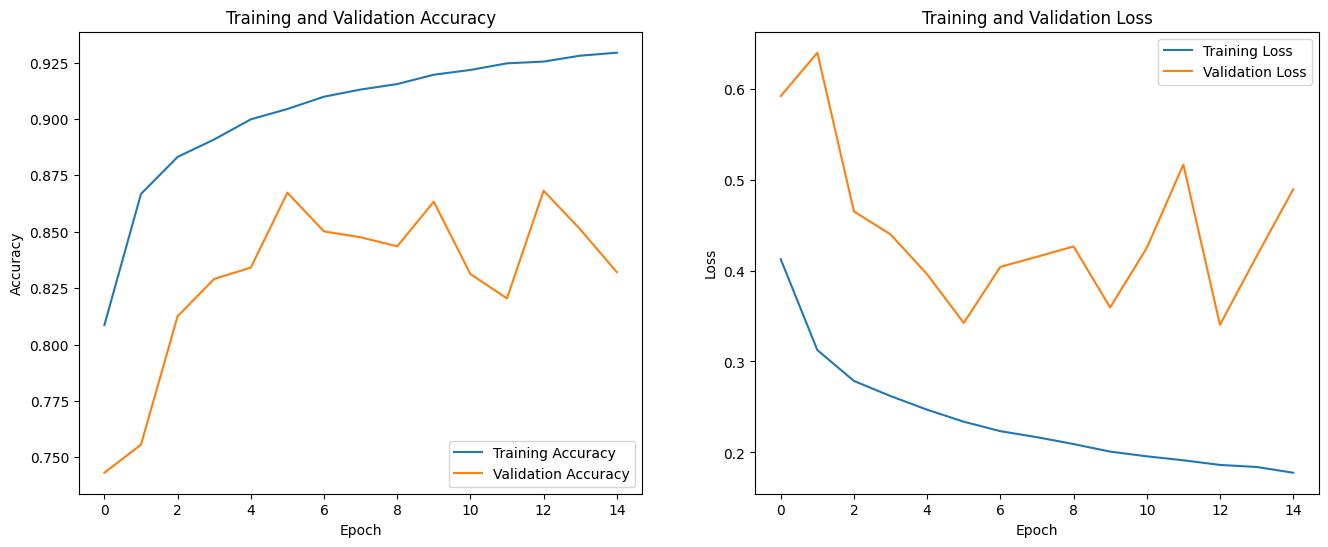


Generating Classification Report and Confusion Matrix...

Classification Report:
              precision    recall  f1-score   support

        FAKE       0.76      0.99      0.86     10000
        REAL       0.99      0.68      0.81     10000

    accuracy                           0.84     20000
   macro avg       0.87      0.84      0.83     20000
weighted avg       0.87      0.84      0.83     20000


Confusion Matrix:


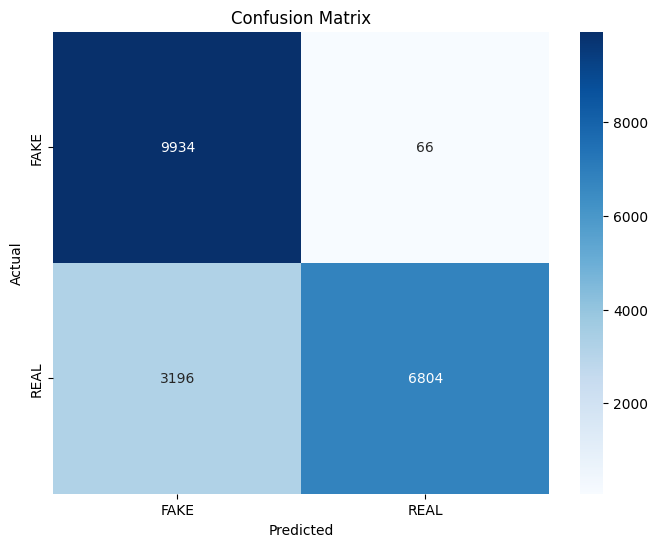

In [ ]:
# ===================================================================
# PHASE 2: EVALUATION AND ANALYSIS
# ===================================================================

# 1. Evaluate on the Test Set
# This is the *true* measure of your model's performance on unseen data.
print("\nEvaluating model on the independent test dataset...")
test_loss, test_accuracy = baseline_model.evaluate(test_dataset)

print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

# 2. Plot Training & Validation History
# This shows us if the model overfitted and how it learned.
print("\nPlotting training history...")
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

# 3. Perform Full Classification Report (Precision, Recall, F1)
# As the plan states, accuracy is not enough.
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

# Get all labels and predictions from the test set
print("\nGenerating Classification Report and Confusion Matrix...")
y_pred = []
y_true = []

for images, labels in test_dataset:
    y_true.extend(labels.numpy().flatten())
    y_pred.extend(baseline_model.predict(images, verbose=0).flatten())

# Convert probabilities (sigmoid output) to binary class labels (0 or 1)
y_pred_binary = (np.array(y_pred) > 0.5).astype(int)

# Print Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_binary, target_names=class_names))

# Plot Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred_binary)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
# ===================================================================
# PHASE 2: (FINAL STEP) Save Baseline Model
# ===================================================================

import numpy as np

# We were already saving the history, but this ensures it
np.save('baseline_history.npy', history.history)
print("Training history saved to 'baseline_history.npy'.")

# Save the model itself
model_filename = 'baseline_cnn_v1.h5'
print(f"Saving baseline model to '{model_filename}'...")
baseline_model.save(model_filename)

print("Model saved. You can download it from the Colab file browser on the left.")
print("This model is now our official baseline.")

# Transfer Learning Model (ResNet-50)

In [ ]:
# ===================================================================
# PHASE 3: ADVANCED MODEL (ResNet-50)
# Task 6: Rebuild Data Pipeline
# ===================================================================

# 1. Define NEW Constants for Transfer Learning
# ResNet-50 was trained on 224x224, but 128x128 is a good,
# fast starting point for our data.
TL_IMG_HEIGHT = 128
TL_IMG_WIDTH = 128
TL_BATCH_SIZE = 32  # Keep batch size the same for now

print(f"Rebuilding data pipeline for {TL_IMG_WIDTH}x{TL_IMG_HEIGHT} images...")

# 2. Create Training and Validation Datasets
train_ds_tl = tf.keras.utils.image_dataset_from_directory(
    train_dir,  # Same directory as before
    label_mode='binary',
    image_size=(TL_IMG_HEIGHT, TL_IMG_WIDTH), # NEW image size
    batch_size=TL_BATCH_SIZE,
    seed=SEED,
    validation_split=0.2,
    subset='training'
)

val_ds_tl = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode='binary',
    image_size=(TL_IMG_HEIGHT, TL_IMG_WIDTH), # NEW image size
    batch_size=TL_BATCH_SIZE,
    seed=SEED,
    validation_split=0.2,
    subset='validation'
)

# 3. Create the Test Dataset
test_ds_tl = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    label_mode='binary',
    image_size=(TL_IMG_HEIGHT, TL_IMG_WIDTH), # NEW image size
    batch_size=TL_BATCH_SIZE,
    shuffle=False
)

# 4. Define Preprocessing for ResNet-50
# ResNet-50 requires a specific preprocessing step.
# It does *not* want pixels in [0, 1]. It wants them preprocessed
# with 'preprocess_input', which scales them to the ImageNet format.
# We also apply our data augmentation.
data_augmentation_tl = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal", seed=SEED),
        tf.keras.layers.RandomRotation(0.1, seed=SEED),
        tf.keras.layers.RandomZoom(0.1, seed=SEED),
    ],
    name="data_augmentation_tl",
)

# ResNet's specific preprocessing layer
preprocess_input = tf.keras.applications.resnet50.preprocess_input

# 5. Apply Preprocessing and Performance Tuning
AUTOTUNE = tf.data.AUTOTUNE

def prepare_tl_dataset(ds, augment=False):
    # Apply ResNet preprocessing
    ds = ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)

    # Cache before augmentation
    #ds = ds.cache()

    if augment:
        ds = ds.map(lambda x, y: (data_augmentation_tl(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)

    # Prefetch for performance
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds

train_ds_tl = prepare_tl_dataset(train_ds_tl, augment=True)
val_ds_tl = prepare_tl_dataset(val_ds_tl, augment=False)
test_ds_tl = prepare_tl_dataset(test_ds_tl, augment=False)

print("\nTransfer learning data pipeline built.")
print("Inspecting one batch from the new training dataset:")
for images, labels in train_ds_tl.take(1):
    print(f"  Images batch shape: {images.shape}")
    print(f"  Min pixel value: {tf.reduce_min(images).numpy()}")
    print(f"  Max pixel value: {tf.reduce_max(images).numpy()}")

In [ ]:
# ===================================================================
# PHASE 3: Task 7: Build Transfer Learning Model
# ===================================================================

from tensorflow.keras.applications import ResNet50

# 1. Load the Pre-trained Base Model
# We load ResNet-50 trained on ImageNet, without its final
# classification layer (include_top=False).
base_model = ResNet50(
    input_shape=(TL_IMG_HEIGHT, TL_IMG_WIDTH, 3),
    include_top=False,  # DO NOT include the final 1000-class layer
    weights='imagenet'  # Use ImageNet weights
)

# 2. Freeze the Base Model
# As per the plan, we freeze the early layers to keep their
# learned features (edges, textures, etc.).
base_model.trainable = False
print(f"\nBase model (ResNet-50) loaded.")
print(f"Base model trainable: {base_model.trainable}")

# 3. Create the New Classification Head
# This is our custom part of the model.
# We will add a GlobalAveragePooling layer to flatten the features,
# then add our own Dense layers, matching the plan's example.
inputs = tf.keras.Input(shape=(TL_IMG_HEIGHT, TL_IMG_WIDTH, 3))

# The base model handles the feature extraction
x = base_model(inputs, training=False) # 'training=False' is critical here

# Flatten the feature maps
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# Add our custom classification layers
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)  # From the plan's example

# Final output layer
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

# 4. Build the Final Model
tl_model = tf.keras.Model(inputs, outputs, name="ResNet50_Transfer")

# 5. Compile the Model
# The plan suggests a lower learning rate (0.0001-0.001) for fine-tuning.
# We'll start with Adam and 0.001.
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 6. Print the Model Summary
# Notice how most parameters are "Non-trainable."
tl_model.summary()


Base model (ResNet-50) loaded.
Base model trainable: False


Model: "ResNet50_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
import numpy as np


Starting transfer learning model training...
Epoch 1/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 300s 120ms/step - accuracy: 0.9604 - loss: 0.1036 - val_accuracy: 0.9598 - val_loss: 0.1108
Epoch 2/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 298s 119ms/step - accuracy: 0.9600 - loss: 0.1054 - val_accuracy: 0.9603 - val_loss: 0.1092
Epoch 3/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 316s 126ms/step - accuracy: 0.9609 - loss: 0.1037 - val_accuracy: 0.9608 - val_loss: 0.1099
Epoch 4/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 303s 121ms/step - accuracy: 0.9608 - loss: 0.0998 - val_accuracy: 0.9592 - val_loss: 0.1185
Epoch 5/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 300s 120ms/step - accuracy: 0.9615 - loss: 0.0993 - val_accuracy: 0.9610 - val_loss: 0.1087
Epoch 6/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 301s 120ms/step - accuracy: 0.9616 - loss: 0.1015 - val_accuracy: 0.9613 - val_loss: 0.1107
Epoch 7/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 301s 120ms/step - accuracy: 0.9639 - loss: 0.0972 - val_accuracy: 0.9595 - val_loss: 0.1159
Epoch 8/10
2500/

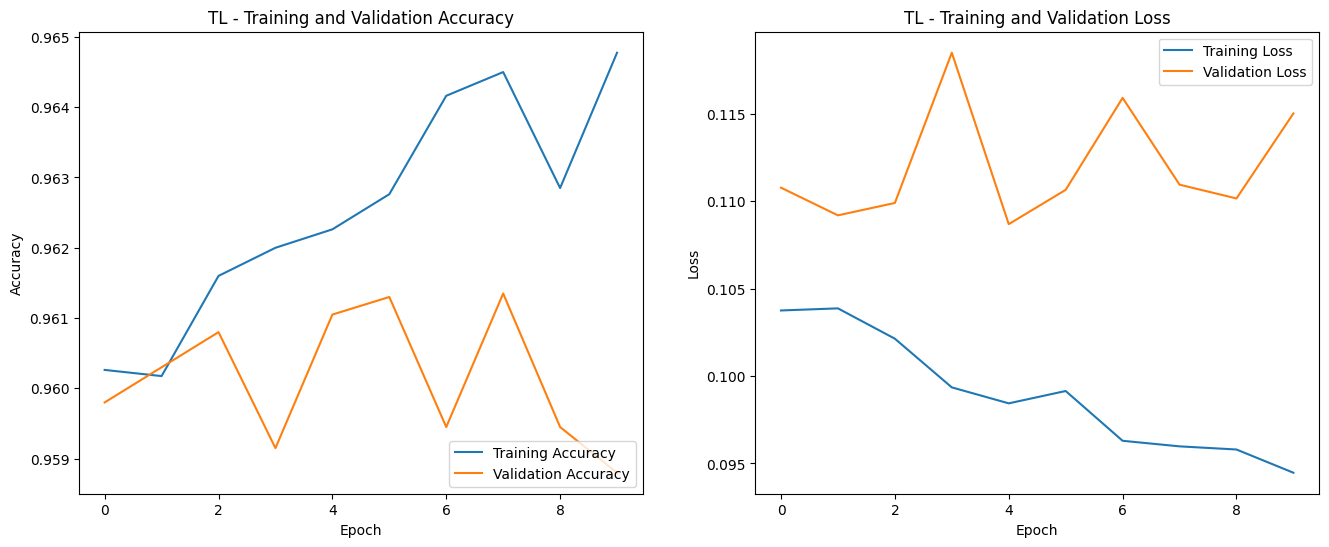


Generating TL Classification Report and Confusion Matrix...

Classification Report (Transfer Learning):
              precision    recall  f1-score   support

        FAKE       0.97      0.95      0.96     10000
        REAL       0.95      0.97      0.96     10000

    accuracy                           0.96     20000
   macro avg       0.96      0.96      0.96     20000
weighted avg       0.96      0.96      0.96     20000


Confusion Matrix (Transfer Learning):


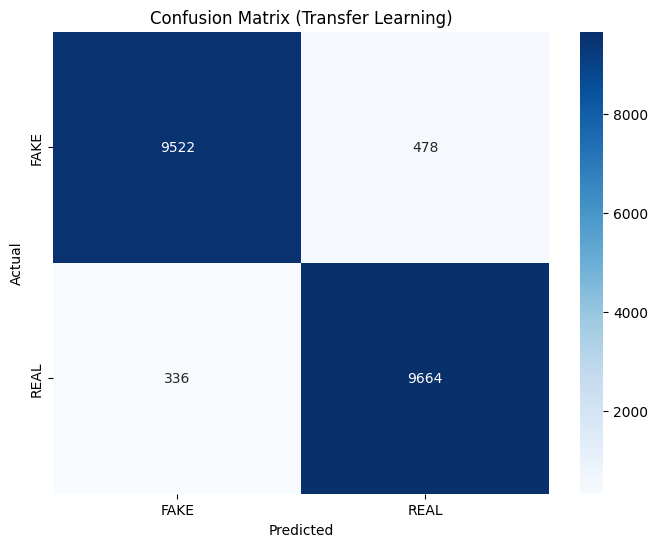

In [ ]:
# ===================================================================
# PHASE 3: Task 8: Train and Evaluate
# ===================================================================

# 1. Train the Model
# We only need a few epochs (10-15) because the base features
# are already learned.
TL_EPOCHS = 10

print("\nStarting transfer learning model training...")

history_tl = tl_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=TL_EPOCHS,
    verbose=1
)

print("\nTransfer learning training complete.")
np.save('tl_history.npy', history_tl.history)

# 2. Evaluate the Transfer Learning Model
print("\nEvaluating transfer learning model on the test dataset...")
tl_test_loss, tl_test_accuracy = tl_model.evaluate(test_ds_tl)

print(f"\nTransfer Learning Test Loss:     {tl_test_loss:.4f}")
print(f"Transfer Learning Test Accuracy: {tl_test_accuracy*100:.2f}%")

# 3. Plot Training History
print("\nPlotting transfer learning training history...")
acc = history_tl.history['accuracy']
val_acc = history_tl.history['val_accuracy']
loss = history_tl.history['loss']
val_loss = history_tl.history['val_loss']

epochs_range = range(TL_EPOCHS)

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('TL - Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('TL - Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

# 4. Generate Full Classification Report
print("\nGenerating TL Classification Report and Confusion Matrix...")
y_pred_tl = []
y_true_tl = []

for images, labels in test_ds_tl:
    y_true_tl.extend(labels.numpy().flatten())
    y_pred_tl.extend(tl_model.predict(images, verbose=0).flatten())

y_pred_binary_tl = (np.array(y_pred_tl) > 0.5).astype(int)

print("\nClassification Report (Transfer Learning):")
print(classification_report(y_true_tl, y_pred_binary_tl, target_names=class_names))

print("\nConfusion Matrix (Transfer Learning):")
cm_tl = confusion_matrix(y_true_tl, y_pred_binary_tl)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Transfer Learning)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
# ===================================================================
# PHASE 3: (FINAL STEP - MODIFIED) Save Champion Model
# ===================================================================

# Save the model in the modern, native Keras format.
# This format is a single file/folder that correctly saves
# the architecture, weights, and optimizer state.
tl_model_filename = 'resnet50_v1.keras'
print(f"Saving transfer learning model to '{tl_model_filename}'...")
tl_model.save(tl_model_filename)

print(f"Model saved as '{tl_model_filename}'.")
print("This is our deployment-ready model.")

Saving transfer learning model to 'resnet50_v1.keras'...
Model saved as 'resnet50_v1.keras'.
This is our deployment-ready model.


In [ ]:
# ===================================================================
# PHASE 4: EXPLAINABLE AI (Grad-CAM)
# Task 10: Install and Setup
# ===================================================================
!pip install tf-keras-vis

print("tf-keras-vis installed.")

In [ ]:
# ===================================================================
# PHASE 4: Task 11 (MANUAL Grad-CAM Implementation - FINAL FIX 3)
# ===================================================================

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import cv2

# 1. --- DEFINE HELPER FUNCTIONS ---

def deprocess_resnet(x):
    """Reverses ResNet preprocessing for display."""
    x = x.copy()
    x[..., 0] += 103.939
    x[..., 1] += 116.779
    x[..., 2] += 123.68
    x = x[..., ::-1] # BGR -> RGB
    x = np.clip(x, 0, 255) / 255.0
    return x

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    """
    Creates a Grad-CAM heatmap.
    """

    # Get the last convolutional layer from *inside* the 'resnet50' layer
    last_conv_layer = model.get_layer('resnet50').get_layer(last_conv_layer_name)

    # --- THIS IS THE FIX ---
    # We pass 'model.inputs' (which is already a list) directly.
    # We DO NOT wrap it in extra brackets [].
    grad_model = tf.keras.models.Model(
        model.inputs, [last_conv_layer.output, model.output]
    )
    # --- END FIX ---

    with tf.GradientTape() as tape:
        # Pass the img_array directly, Keras will handle the list wrapping
        last_conv_layer_output, preds = grad_model(img_array)
        class_output = preds[:, 0]

    grads = tape.gradient(class_output, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

# 2. --- SETUP AND EXECUTE ---
model = tl_model # Use the in-memory model
last_conv_layer_name = "conv5_block3_out"
print(f"Targeting last conv/activation layer: '{last_conv_layer_name}'")

images, labels = next(iter(test_ds_tl))
images_np = images.numpy()
labels_np = labels.numpy().flatten().astype(int)

print("Generating manual Grad-CAM heatmaps...")

# 3. --- PLOT THE RESULTS ---
num_to_show = 6
fig, axs = plt.subplots(2, num_to_show, figsize=(20, 8))

for i in range(num_to_show):
    img = images_np[i]
    label = labels_np[i]
    img_batch = np.expand_dims(img, axis=0)

    pred_prob = model.predict(img_batch, verbose=0)[0][0]
    pred_class = (pred_prob > 0.5).astype(int)

    heatmap = make_gradcam_heatmap(img_batch, model, last_conv_layer_name)

    heatmap_resized = cv2.resize(heatmap, (TL_IMG_WIDTH, TL_IMG_HEIGHT))
    heatmap_jet = np.uint8(plt.cm.jet(heatmap_resized)[..., :3] * 255)
    img_display = deprocess_resnet(img)

    # Plot Original Image
    axs[0, i].imshow(img_display)
    axs[0, i].axis('off')
    title_color = 'g' if pred_class == label else 'r'
    axs[0, i].set_title(f"Actual: {class_names[label]}\nPred: {class_names[pred_class]} ({pred_prob:.2f})", color=title_color)

    # Plot Heatmap
    axs[1, i].imshow(img_display)
    axs[1, i].imshow(heatmap_jet, cmap='jet', alpha=0.5)
    axs[1, i].axis('off')
    axs[1, i].set_title("Grad-CAM")

plt.tight_layout()
plt.show()